# TP 4 | Manipulation de vidéos avec OpenCV

**Vidéo utilisée :** `vtest.avi`, clip d'exemple fourni par OpenCV (piétons filmés par une caméra fixe). Caméra fixe + sujets en mouvement : idéal pour la question 7.

| # | Tâche |
|---|-------|
| 1 | Charger un petit clip vidéo |
| 2 | Lire les métadonnées (fps, nombre de frames, durée) |
| 3 | Afficher la vidéo dans le notebook |
| 4 | Extraire 3 frames/seconde et les afficher |
| 5 | Sauvegarder les frames dans un dossier |
| 6 | Modifier le fps et comparer vidéo originale / modifiée |
| 7 | Différence entre deux frames successives |

## 0. Configuration

Dépendances : `opencv-python`, `numpy`, `matplotlib`, `imageio-ffmpeg`.

`imageio-ffmpeg` fournit l'exécutable **ffmpeg** : il sert uniquement à convertir les vidéos en MP4 **H.264**, seul format lisible par le lecteur vidéo du notebook (navigateur). OpenCV fait tout le reste.

In [1]:
from pathlib import Path
import base64
import subprocess
import urllib.request

import cv2
import imageio_ffmpeg
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Video, display

WORK_DIR = Path("tp4_data")          # dossier de travail
FRAMES_DIR = WORK_DIR / "frames"     # frames extraites (question 5)
WORK_DIR.mkdir(exist_ok=True)

FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()
print(f"OpenCV {cv2.__version__}")

OpenCV 5.0.0


In [2]:
def to_h264(src, dst, duration=None):
    # Convertit une vidéo en MP4 H.264 (lisible dans le notebook)
    cmd = [FFMPEG, "-y", "-loglevel", "error", "-i", str(src)]
    if duration is not None:
        cmd += ["-t", str(duration)]              # ne garde que les `duration` premières secondes
    cmd += ["-c:v", "libx264", "-pix_fmt", "yuv420p", str(dst)]
    subprocess.run(cmd, check=True)


def get_metadata(path):
    # Lit fps, nombre de frames, taille et durée d'une vidéo
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return {"fps": fps, "frames": n_frames, "largeur": width, "hauteur": height, "durée (s)": n_frames / fps}


def show_videos(paths, titles, width=380):
    # Affiche plusieurs vidéos côte à côte (intégrées en base64 dans le notebook)
    blocks = []
    for p, t in zip(paths, titles):
        b64 = base64.b64encode(Path(p).read_bytes()).decode()
        blocks.append(
            f'<div style="text-align:center"><b>{t}</b><br>'
            f'<video width="{width}" controls loop><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video></div>'
        )
    display(HTML('<div style="display:flex;gap:12px;flex-wrap:wrap">' + "".join(blocks) + "</div>"))

---
## 1. Charger un petit clip vidéo

On télécharge la vidéo, puis on garde les **10 premières secondes** converties en MP4 H.264 : c'est notre clip de travail.

Vidéo ouverte : True


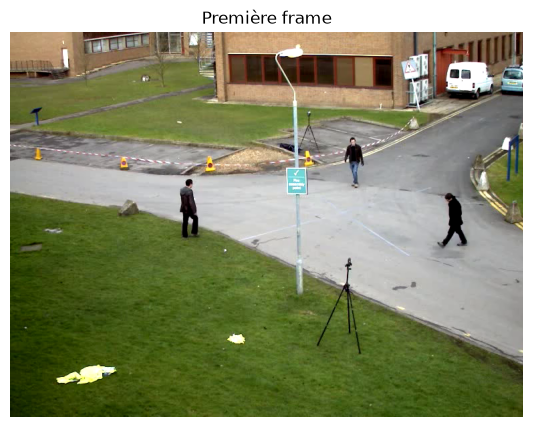

In [3]:
URL = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/vtest.avi"
SOURCE = WORK_DIR / "vtest.avi"
CLIP = WORK_DIR / "clip.mp4"

if not SOURCE.exists():
    urllib.request.urlretrieve(URL, SOURCE)
to_h264(SOURCE, CLIP, duration=10)

cap = cv2.VideoCapture(str(CLIP))           # ouvre la vidéo
print("Vidéo ouverte :", cap.isOpened())

ok, first = cap.read()                      # lit la 1re frame : ok=True si réussi, frame en BGR
cap.release()                               # libère le fichier

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(first, cv2.COLOR_BGR2RGB))
plt.title("Première frame")
plt.axis("off")
plt.show()

Une vidéo est une **suite d'images** (frames). `cv2.VideoCapture` ouvre le fichier et `cap.read()` renvoie la frame suivante à chaque appel, au format BGR comme `cv2.imread`.

---
## 2. Lire les métadonnées

| Propriété OpenCV | Signification |
|---|---|
| `CAP_PROP_FPS` | images par seconde |
| `CAP_PROP_FRAME_COUNT` | nombre total de frames |
| `CAP_PROP_FRAME_WIDTH` / `HEIGHT` | taille des frames |

Durée = nombre de frames / fps.

In [4]:
meta = get_metadata(CLIP)
for k, v in meta.items():
    print(f"{k:<10}: {v:g}")

FPS = meta["fps"]

fps       : 10
frames    : 100
largeur   : 768
hauteur   : 576
durée (s) : 10


---
## 3. Afficher la vidéo dans le notebook

`IPython.display.Video` avec `embed=True` intègre la vidéo dans le notebook (elle reste visible après fermeture).

In [5]:
Video(str(CLIP), embed=True, width=600)

---
## 4. Extraire 3 frames par seconde

La vidéo est à `FPS` images/s. Pour en garder 3 par seconde, on vise les instants `t = 0, 1/3, 2/3, 1, ...` et on prend la frame la plus proche : `indice = round(t * FPS)`.

In [6]:
TARGET_FPS = 3

duration = meta["frames"] / FPS
times = np.arange(0, duration, 1 / TARGET_FPS)                  # instants voulus (s)
wanted = {int(round(t * FPS)): t for t in times}                # indice de frame -> instant

extracted = []                                                   # liste de (instant, frame RGB)
cap = cv2.VideoCapture(str(CLIP))
idx = 0
while True:
    ok, frame = cap.read()
    if not ok:                                                   # fin de la vidéo
        break
    if idx in wanted:
        extracted.append((wanted[idx], cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    idx += 1
cap.release()

print(f"{len(extracted)} frames extraites sur {idx} ({TARGET_FPS} par seconde pendant {duration:.0f} s)")
print("Indices :", sorted(wanted))

30 frames extraites sur 100 (3 par seconde pendant 10 s)
Indices : [0, 3, 7, 10, 13, 17, 20, 23, 27, 30, 33, 37, 40, 43, 47, 50, 53, 57, 60, 63, 67, 70, 73, 77, 80, 83, 87, 90, 93, 97]


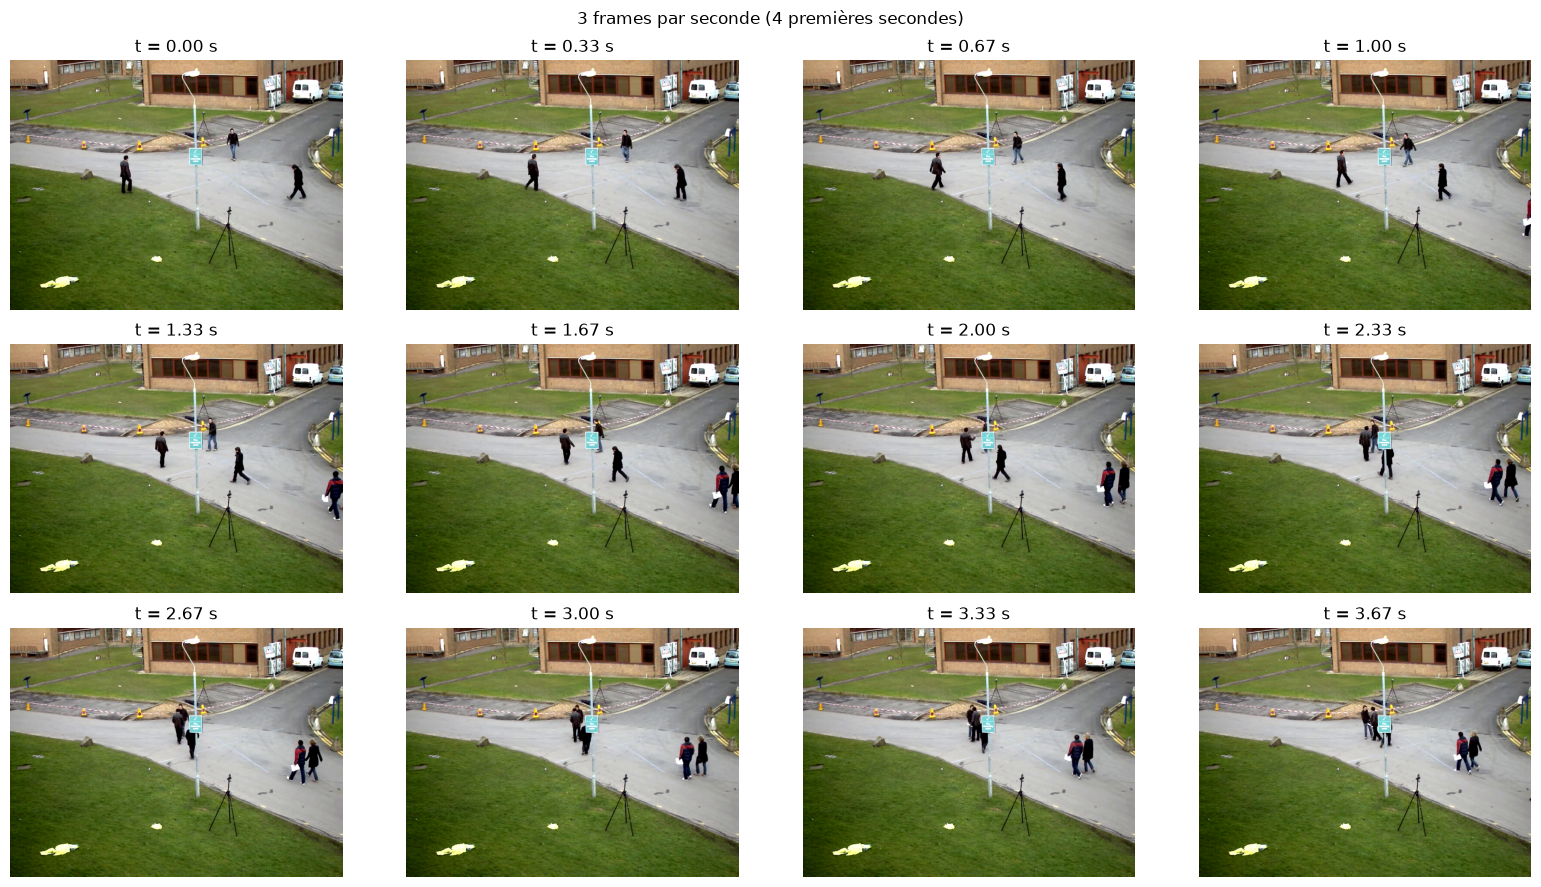

In [7]:
shown = extracted[:12]                                           # les 4 premières secondes
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, (t, fr) in zip(axes.ravel(), shown):
    ax.imshow(fr)
    ax.set_title(f"t = {t:.2f} s")
    ax.axis("off")
plt.suptitle("3 frames par seconde (4 premières secondes)")
plt.tight_layout()
plt.show()

---
## 5. Sauvegarder les frames dans un dossier

`cv2.imwrite` attend du **BGR** : on reconvertit avant d'écrire. Le nom de fichier contient l'instant, pour retrouver l'origine de chaque image.

In [8]:
FRAMES_DIR.mkdir(parents=True, exist_ok=True)
for old in FRAMES_DIR.glob("*.jpg"):                             # vide le dossier si on relance
    old.unlink()

for i, (t, fr) in enumerate(extracted):
    name = FRAMES_DIR / f"frame_{i:03d}_t{t:05.2f}s.jpg"
    cv2.imwrite(str(name), cv2.cvtColor(fr, cv2.COLOR_RGB2BGR))

saved = sorted(FRAMES_DIR.glob("*.jpg"))
print(f"{len(saved)} fichiers dans {FRAMES_DIR}/ :")
for f in saved[:5]:
    print("  ", f.name)
print("   ...")

30 fichiers dans tp4_data\frames/ :
   frame_000_t00.00s.jpg
   frame_001_t00.33s.jpg
   frame_002_t00.67s.jpg
   frame_003_t01.00s.jpg
   frame_004_t01.33s.jpg
   ...


---
## 6. Modifier le fps et comparer

On reconstruit des vidéos avec `cv2.VideoWriter` en jouant sur deux paramètres :
- le **fps d'écriture** (vitesse de lecture) ;
- le **nombre de frames conservées**.

| Version | Frames utilisées | fps d'écriture | Effet attendu |
|---|---|---|---|
| Originale | toutes (100) | 10 | référence |
| Ralentie | toutes (100) | 5 | 2x plus lente, durée x2 |
| Accélérée | toutes (100) | 20 | 2x plus rapide, durée /2 |
| Saccadée | 3 par seconde (30) | 3 | même durée, mouvement saccadé |

In [9]:
def read_all_frames(path):
    cap = cv2.VideoCapture(str(path))
    frames = []
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        frames.append(fr)                                       # on garde le BGR pour VideoWriter
    cap.release()
    return frames


def write_video(frames, fps, path):
    # Écrit les frames avec OpenCV, puis convertit en H.264 pour l'affichage
    h, w = frames[0].shape[:2]
    tmp = path.with_suffix(".tmp.mp4")
    writer = cv2.VideoWriter(str(tmp), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))  # taille = (largeur, hauteur)
    for fr in frames:
        writer.write(fr)
    writer.release()
    to_h264(tmp, path)
    tmp.unlink()


all_frames = read_all_frames(CLIP)
sub_frames = [cv2.cvtColor(fr, cv2.COLOR_RGB2BGR) for _, fr in extracted]   # frames de la question 4

versions = {
    "Originale (10 fps)": CLIP,
    "Ralentie (5 fps)": WORK_DIR / "slow_5fps.mp4",
    "Accélérée (20 fps)": WORK_DIR / "fast_20fps.mp4",
    "Saccadée (3 fps)": WORK_DIR / "choppy_3fps.mp4",
}
write_video(all_frames, FPS / 2, versions["Ralentie (5 fps)"])
write_video(all_frames, FPS * 2, versions["Accélérée (20 fps)"])
write_video(sub_frames, TARGET_FPS, versions["Saccadée (3 fps)"])

print(f"{'Version':<22}{'fps':>6}{'frames':>8}{'durée (s)':>11}")
print("-" * 47)
for name, p in versions.items():
    m = get_metadata(p)
    print(f"{name:<22}{m['fps']:>6g}{m['frames']:>8}{m['durée (s)']:>11.1f}")

Version                  fps  frames  durée (s)
-----------------------------------------------
Originale (10 fps)        10     100       10.0
Ralentie (5 fps)           5     100       20.0
Accélérée (20 fps)        20     100        5.0
Saccadée (3 fps)           3      30       10.0


In [10]:
show_videos(list(versions.values()), list(versions.keys()), width=380)

### Comparaison

- **Ralentie / accélérée** : les frames sont **identiques** à l'original, seul le fps d'écriture change. La vidéo dure 2x plus ou 2x moins longtemps et les piétons marchent plus lentement ou plus vite. Le fps ne stocke aucune image : il indique seulement **à quelle vitesse les afficher**.
- **Saccadée** : on a supprimé des frames et adapté le fps. La durée est inchangée, mais le mouvement devient **haché** car l'œil perçoit un mouvement fluide à partir d'environ 20-25 images/s. Le fichier contient 3x moins d'images, donc il est plus léger.
- Conséquence : réduire le fps d'une vidéo permet d'alléger le traitement (ex. analyser 3 frames/s au lieu de 10), au prix d'une perte d'information temporelle.

---
## 7. Différence entre deux frames successives

On calcule, pixel par pixel, `|frame(t+1) - frame(t)|` en niveaux de gris avec `cv2.absdiff`, puis on garde uniquement les différences significatives avec un **seuil** (pour ignorer le bruit du capteur et de la compression).

Différence moyenne : 1.65 niveaux | pixels modifiés : 1.15 %


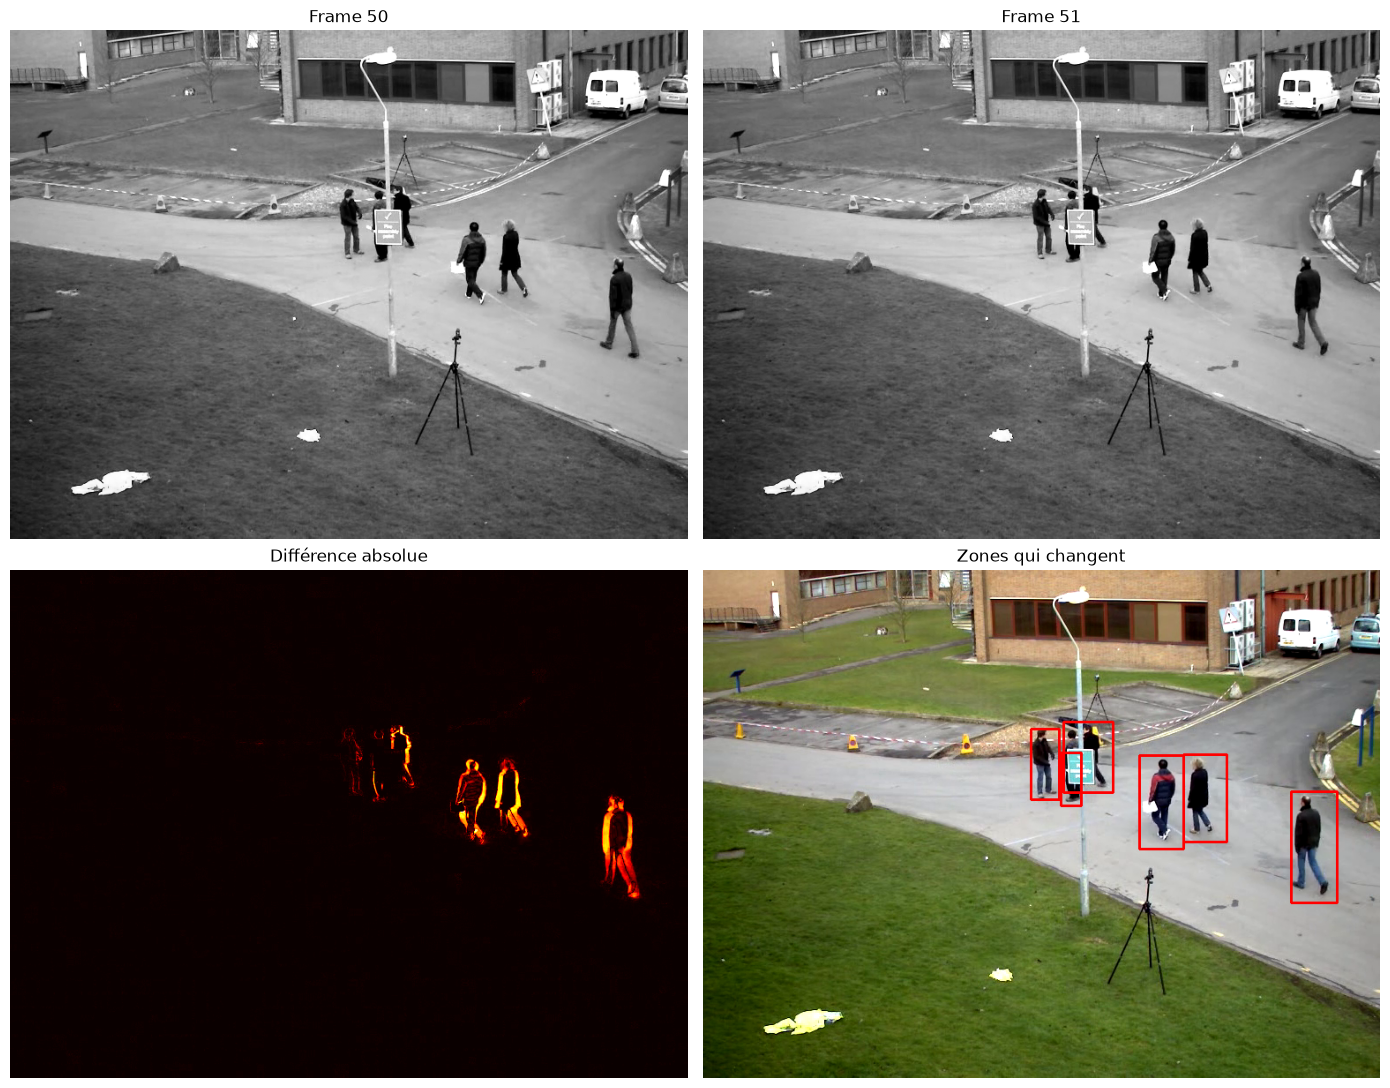

In [11]:
i = 50                                                           # frame choisie (t = 5 s)
f1 = cv2.cvtColor(all_frames[i], cv2.COLOR_BGR2GRAY)
f2 = cv2.cvtColor(all_frames[i + 1], cv2.COLOR_BGR2GRAY)

diff = cv2.absdiff(f1, f2)                                       # valeur absolue : évite le débordement uint8
_, mask = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)       # changement > 25 niveaux -> blanc

changed = mask.mean() / 255 * 100
print(f"Différence moyenne : {diff.mean():.2f} niveaux | pixels modifiés : {changed:.2f} %")

# Rectangle autour de chaque zone en mouvement
mask_clean = cv2.dilate(mask, np.ones((5, 5), np.uint8), iterations=2)   # relie les pixels voisins
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
boxed = cv2.cvtColor(all_frames[i + 1], cv2.COLOR_BGR2RGB)
for c in contours:
    if cv2.contourArea(c) > 100:                                 # ignore les petites taches
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(boxed, (x, y), (x + w, y + h), (255, 0, 0), 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
panels = [(f1, f"Frame {i}", "gray"), (f2, f"Frame {i + 1}", "gray"),
          (diff, "Différence absolue", "hot"), (boxed, "Zones qui changent", None)]
for ax, (im, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

Entre deux frames successives (0,1 s d'écart), le mouvement est faible. Comparons avec des écarts plus grands :

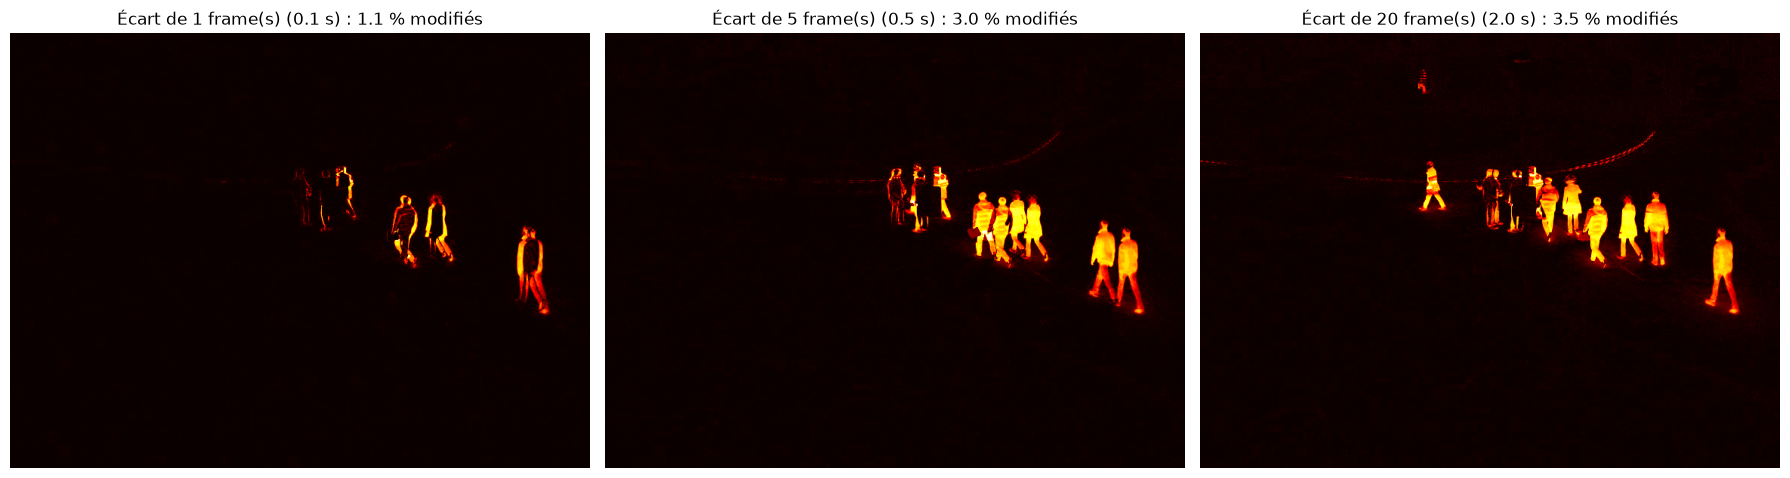

In [12]:
gaps = [1, 5, 20]
fig, axes = plt.subplots(1, len(gaps), figsize=(18, 5))
for ax, g in zip(axes, gaps):
    a = cv2.cvtColor(all_frames[i], cv2.COLOR_BGR2GRAY)
    b = cv2.cvtColor(all_frames[i + g], cv2.COLOR_BGR2GRAY)
    d = cv2.absdiff(a, b)
    pct = (d > 25).mean() * 100
    ax.imshow(d, cmap="hot")
    ax.set_title(f"Écart de {g} frame(s) ({g / FPS:.1f} s) : {pct:.1f} % modifiés")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Quelles parties de l'image changent ?

- **Ce qui change** : uniquement les **piétons en mouvement**. La différence est forte sur leurs **contours** (bords des silhouettes, jambes, bras) : c'est là qu'un pixel passe du fond au personnage, ou l'inverse.
- **Ce qui ne change pas** : tout le **fond statique** (sol, bâtiments, mobilier urbain), car la caméra est fixe. La différence y est quasi nulle ; les faibles valeurs restantes sont du **bruit** (capteur, compression), éliminé par le seuil.
- **L'intérieur des personnages** change peu : une zone de couleur uniforme qui se déplace légèrement reste semblable à elle-même.
- Plus l'écart entre frames augmente, plus les zones modifiées sont grandes : les personnages ont eu le temps de se déplacer davantage. Chaque personne apparaît alors **deux fois** (ancienne et nouvelle position), et de petits mouvements deviennent visibles, comme le ruban de chantier qui bouge avec le vent.

C'est le principe de la **détection de mouvement** par différence de frames (vidéosurveillance, compression vidéo : seules les zones qui changent sont réellement encodées).

---
## Conclusion

| Notion | À retenir |
|---|---|
| Lecture | `cv2.VideoCapture` + `cap.read()` en boucle, frames en BGR |
| Métadonnées | `CAP_PROP_FPS`, `CAP_PROP_FRAME_COUNT` ; durée = frames / fps |
| Affichage | MP4 H.264 + `IPython.display.Video(embed=True)` |
| Échantillonnage | indice = round(t x fps) pour extraire N frames/s |
| Écriture | `cv2.VideoWriter(path, fourcc, fps, (largeur, hauteur))` |
| fps | change la vitesse de lecture ; supprimer des frames rend le mouvement saccadé |
| Différence | `cv2.absdiff` + seuil : met en évidence les objets en mouvement |